In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# drop id, format bmi, remove 'Other' gender
df = df.drop(columns=['id'])
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df = df[df['gender'] != 'Other'].copy()

X = df.drop('stroke', axis=1)
y = df['stroke']

# split first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  163
smoking_status         0
stroke                 0
dtype: int64
               age  avg_glucose_level          bmi
count  4087.000000        4087.000000  3924.000000
mean     43.259369         105.895087    28.881957
std      22.642243          44.676845     7.895163
min       0.080000          55.220000    10.300000
25%      25.000000          77.455000    23.500000
50%      45.000000          91.890000    28.100000
75%      61.000000         114.035000    33.100000
max      82.000000         271.740000    97.600000


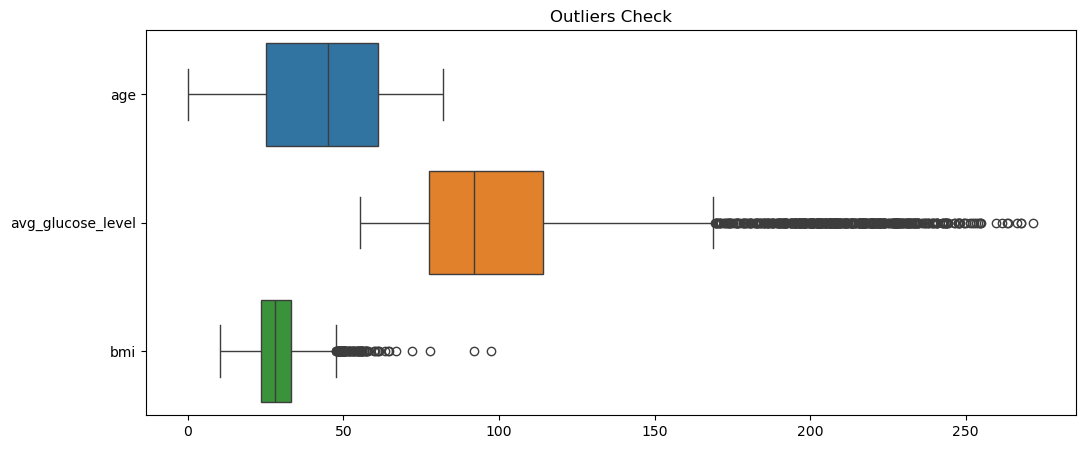

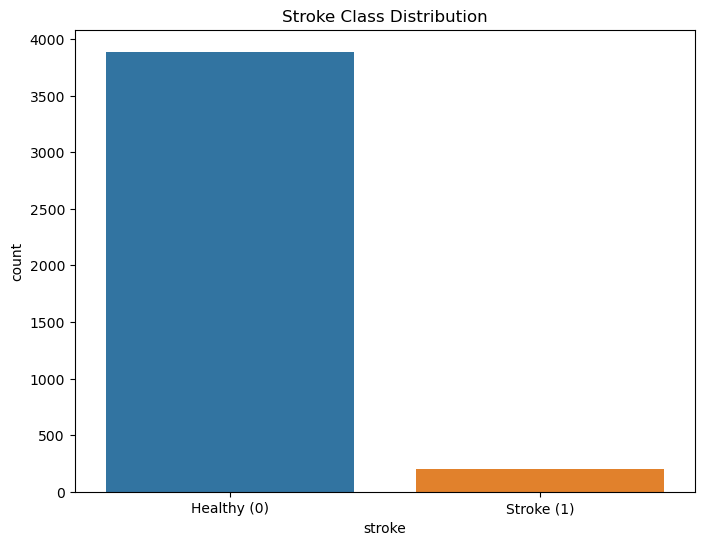

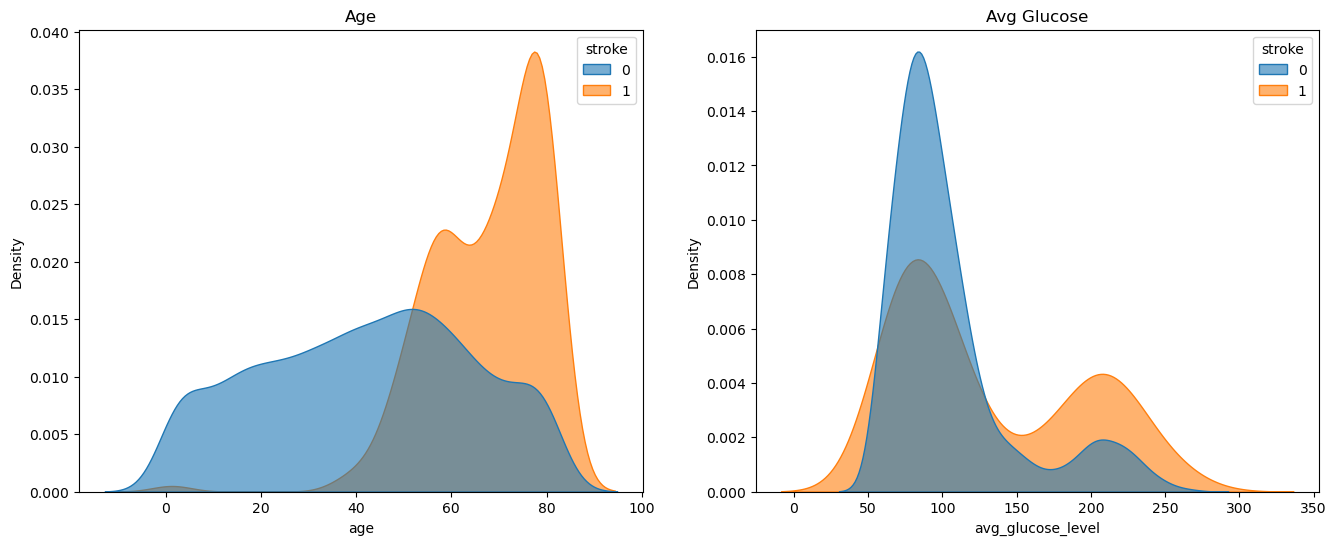

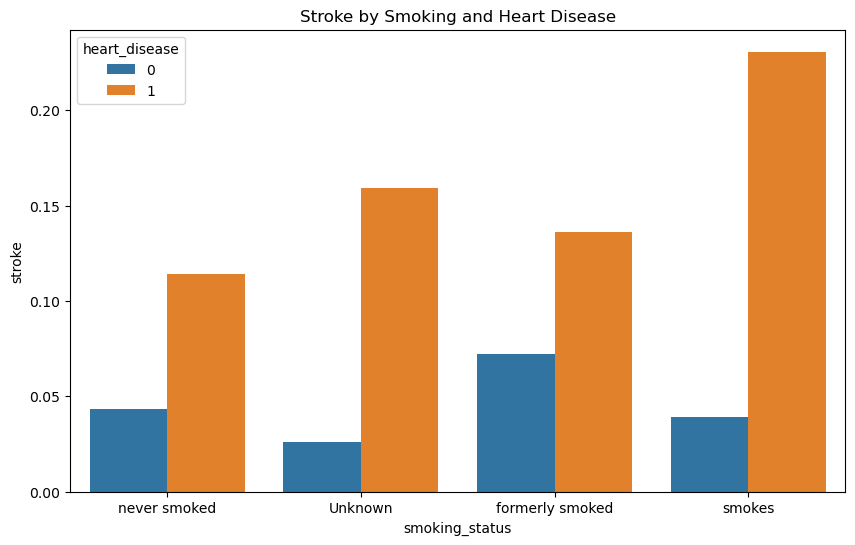

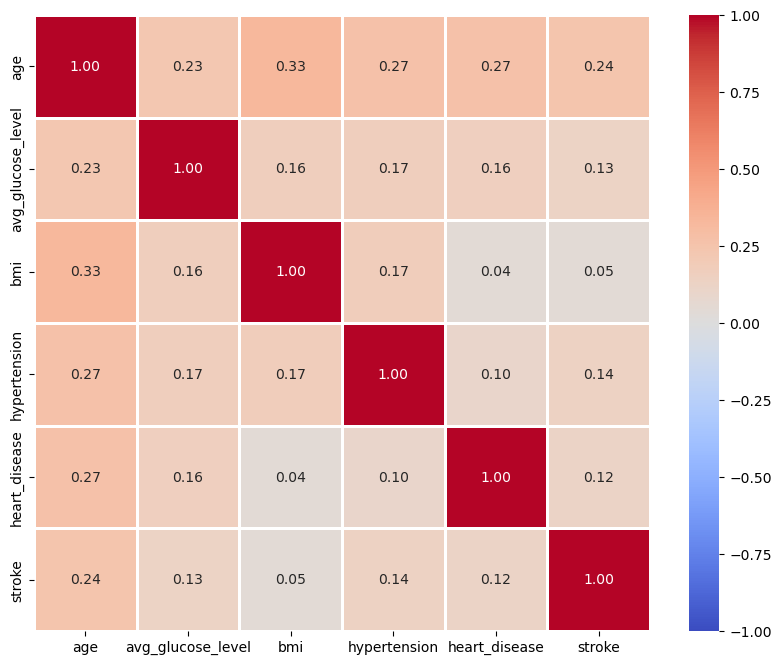

In [3]:
# eda on training set only
df_train_eda = pd.concat([X_train, y_train], axis=1)

# check missing values
print(df_train_eda.isnull().sum())

# summary statistics for numerical features
print(df_train_eda[['age', 'avg_glucose_level', 'bmi']].describe())

# boxplots for outliers
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_train_eda[['age', 'avg_glucose_level', 'bmi']], orient="h")
plt.title('Outliers Check')
plt.show()

# stroke distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train_eda, x='stroke', hue='stroke', legend=False)
plt.xticks(ticks=[0, 1], labels=['Healthy (0)', 'Stroke (1)'])
plt.title('Stroke Class Distribution')
plt.show()

# age and glucose kde
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(data=df_train_eda, x='age', hue='stroke', fill=True, common_norm=False, ax=axes[0], alpha=0.6)
axes[0].set_title('Age')
sns.kdeplot(data=df_train_eda, x='avg_glucose_level', hue='stroke', fill=True, common_norm=False, ax=axes[1], alpha=0.6)
axes[1].set_title('Avg Glucose')
plt.show()

# smoking, heart disease and stroke
plt.figure(figsize=(10, 6))
sns.barplot(data=df_train_eda, x='smoking_status', y='stroke', hue='heart_disease', errorbar=None)
plt.title('Stroke by Smoking and Heart Disease')
plt.show()

# correlation heatmap
num_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
plt.figure(figsize=(10, 8))
sns.heatmap(df_train_eda[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=1)
plt.show()

In [5]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# knn imputation for bmi
X_train_tmp = X_train.copy()
X_test_tmp = X_test.copy()
X_train_tmp['gender_num'] = X_train_tmp['gender'].map({'Male': 0, 'Female': 1})
X_test_tmp['gender_num'] = X_test_tmp['gender'].map({'Male': 0, 'Female': 1})

imputer = KNNImputer(n_neighbors=5)
impute_features = ['age', 'gender_num', 'avg_glucose_level', 'bmi']

# fit on train, transform both
imputer.fit(X_train_tmp[impute_features])
X_train['bmi'] = imputer.transform(X_train_tmp[impute_features])[:, 3]
X_test['bmi'] = imputer.transform(X_test_tmp[impute_features])[:, 3]

# one-hot encoding
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# align columns in case test set misses some categories
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# standard scaling
scaler = StandardScaler()
num_features = ['age', 'avg_glucose_level', 'bmi']

X_train_encoded[num_features] = scaler.fit_transform(X_train_encoded[num_features])
X_test_encoded[num_features] = scaler.transform(X_test_encoded[num_features])